In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install split-folders kagglehub ultralytics

import kagglehub
import splitfolders
import os

print("Baixando dataset do Kaggle...")
path = kagglehub.dataset_download("mostafaabla/garbage-classification")
print("Dataset baixado na pasta temporária:", path)

pasta_classes = path
for root, dirs, files in os.walk(path):
    if 'metal' in dirs and 'paper' in dirs:
        pasta_classes = root
        break

print(f"Organizando as imagens a partir de: {pasta_classes}")

splitfolders.ratio(
    pasta_classes,
    output="/content/dataset_yolo",
    seed=42,
    ratio=(0.8, 0.2)
)
print("Dataset organizado com sucesso no formato YOLO!")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.6 MB/s eta 0:00:00
Baixando dataset do Kaggle...


100%|██████████| 239M/239M [00:01<00:00, 155MB/s]

Extracting files...


Dataset baixado na pasta temporária: /root/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1
Organizando as imagens a partir de: /root/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1/garbage_classification


Copying files: 15515 files [00:04, 3788.81 files/s]

Dataset organizado com sucesso no formato YOLO!


In [2]:
from ultralytics import YOLO

model = YOLO('yolov8n-cls.pt')

model.train(
  data='/content/dataset_yolo',
  epochs=150,
  patience=15,
  imgsz=224,
  device=0, # Usa GPU
  project='/content/drive/MyDrive/EcoSort_Modelos', # salva no drive
  name='modelo_classificacao_v2'
)

print("Treinamento concluído e salvo no Google Drive com sucesso!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.28 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolo, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, 

Faça o upload de uma imagem:


Saving 11203450-hamburguer-de-carne-meio-comido-na-mesa-close-up-foto.jpg to 11203450-hamburguer-de-carne-meio-comido-na-mesa-close-up-foto.jpg

image 1/1 /content/11203450-hamburguer-de-carne-meio-comido-na-mesa-close-up-foto.jpg: 224x224 biological 1.00, paper 0.00, metal 0.00, clothes 0.00, plastic 0.00, 6.1ms
Speed: 11.9ms preprocess, 6.1ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Results saved to /content/runs/classify/predict20

--- RESULTADO DA CLASSIFICAÇÃO ---
O modelo classificou o resíduo como: BIOLOGICAL
Certeza de: 100.00%

--- JSON GERADO PARA ENVIO À API ---
{
  "lixeira_id": "smart_bin_01",
  "timestamp": "2026-03-26T16:54:55.765748+00:00",
  "detection": {
    "class_name": "biological",
    "confidence": 1.0
  }
}


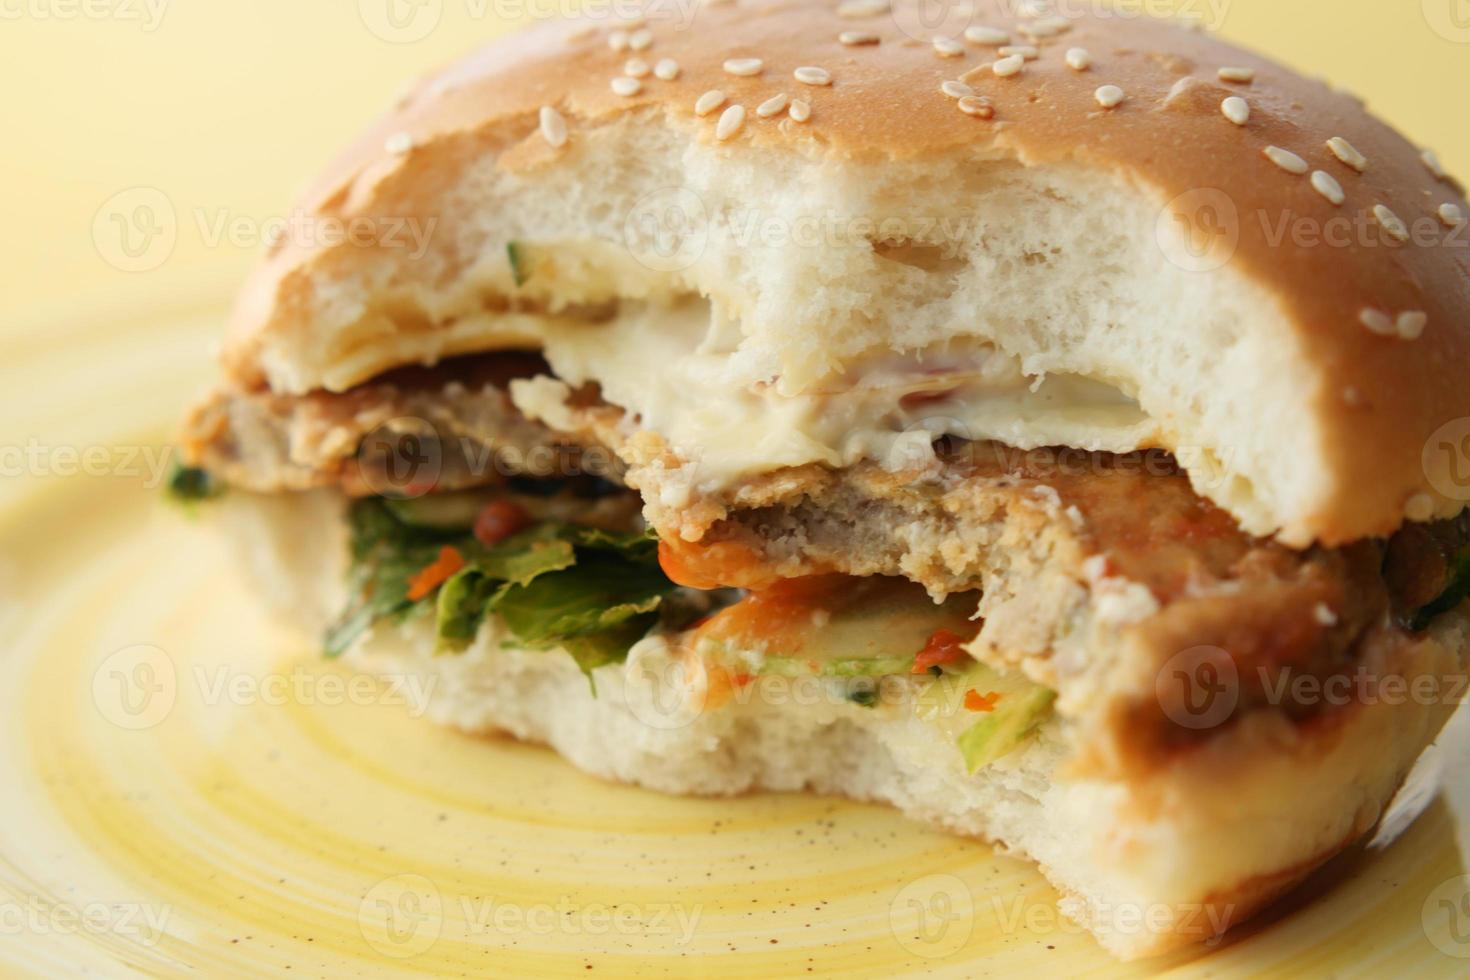

In [23]:
from ultralytics import YOLO
from google.colab import files
import IPython.display as display
import json
from datetime import datetime, timezone

caminho_do_modelo = '/content/drive/MyDrive/EcoSort_Modelos/modelo_classificacao_v2/weights/best.pt'
modelo_treinado = YOLO(caminho_do_modelo)

print("Faça o upload de uma imagem:")
uploaded = files.upload()

for nome_arquivo in uploaded.keys():
    caminho_imagem = f"/content/{nome_arquivo}"

    resultados = modelo_treinado.predict(source=caminho_imagem, save=True)

    for resultado in resultados:
        indice_maior_chance = resultado.probs.top1
        nome_da_classe = resultado.names[indice_maior_chance]
        certeza = resultado.probs.top1conf.item()

        payload = {
            "lixeira_id": "smart_bin_01",
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "detection": {
                "class_name": nome_da_classe,
                "confidence": round(certeza, 4)
            }
        }

        print(f"\n--- RESULTADO DA CLASSIFICAÇÃO ---")
        print(f"O modelo classificou o resíduo como: {nome_da_classe.upper()}")
        print(f"Certeza de: {certeza * 100:.2f}%\n")

        print("--- JSON GERADO PARA ENVIO À API ---")
        print(json.dumps(payload, indent=2))

        display.display(display.Image(filename=caminho_imagem))